In [10]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import h5py
import torch
import umap_pytorch
np.__version__, torch.__version__, umap_pytorch

('2.0.2',
 '2.8.0+cpu',
 <module 'umap_pytorch' from '/mnt/efsUCE/umap_pytorch/umap_pytorch/__init__.py'>)

In [2]:
model_dir = "PUMAP/pytorch_45M_knn20_Brain_NervousSystem"
existing_model_iteration = 15

results_dir = "combined_UCE_45M"
pca_file = "pca_Brain_NervousSystem.h5"
cell_type_file = "cell_type_Brain_NervousSystem.tsv.gz"

In [3]:
# Load model back
from umap_pytorch import load_pumap
path = os.path.join(model_dir, f'pytorch_{existing_model_iteration}.pkl')
pumap = load_pumap(path)
print("Loaded model", f'pytorch_{existing_model_iteration}.pkl')

Loading PUMAP object from pickled file.
Loaded model pytorch_15.pkl


In [3]:
# Load the PCA-transformed data
with h5py.File(os.path.join(results_dir, pca_file), "r") as f:
    X_pca = f["pca"][:]
print(X_pca.shape)

(13991888, 50)


In [4]:
subset_indices = np.random.choice(X_pca.shape[0], 1_000_000, replace=False)

In [16]:
data_tensor = torch.from_numpy(X_pca[subset_indices,:])
data_tensor, data_tensor.shape, data_tensor.dtype

(tensor([[-0.4814,  0.0500, -0.0717,  ..., -0.0125, -0.0226, -0.0325],
         [-0.2723,  0.0750, -0.1016,  ..., -0.0049,  0.0810, -0.0012],
         [-0.4240,  0.1251, -0.2461,  ...,  0.0167, -0.0160, -0.0108],
         ...,
         [-0.0066, -0.7459, -0.2816,  ..., -0.0144, -0.0095,  0.0056],
         [-0.1688,  0.0485, -0.0678,  ..., -0.0353,  0.0016,  0.0018],
         [ 0.3887,  0.2009, -0.0979,  ..., -0.0228, -0.1062,  0.0332]]),
 torch.Size([1000000, 50]),
 torch.float32)

In [17]:
# batch transform
batch_size = 1_000_000
embedding_dim = 2   # since n_components=2
n_samples = data_tensor.shape[0]

# Preallocate result array
X_umap_pytorch = np.zeros((n_samples, embedding_dim), dtype=np.float32)

# Loop over batches
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    batch = data_tensor[start:end]
    emb = pumap.transform(batch) ### transformation
    X_umap_pytorch[start:end] = emb

print("✅ Done. Final embedding shape:", X_umap_pytorch.shape)

Reducing array of shape torch.Size([1000000, 50]) to (1000000, 2)
✅ Done. Final embedding shape: (1000000, 2)


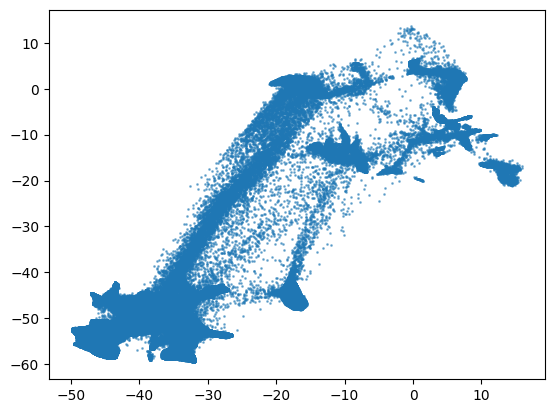

In [18]:
plt.scatter(X_umap_pytorch[:,0], X_umap_pytorch[:,1], alpha =0.5, s=1)
plt.show()

In [5]:
cell_type = pd.read_csv(os.path.join(results_dir, cell_type_file), sep ='\t', index_col = 0)

In [6]:
coord_data = X_pca[subset_indices]  # need adjustment, hard-code to pca

In [7]:
plot_data = cell_type.iloc[subset_indices]
assert (len(plot_data) == coord_data.shape[0])

In [8]:
# Extract the cell_type column
labels = plot_data["cell_type"].astype(str).values
encoded_labels, unique_labels = pd.factorize(labels)
len(unique_labels)

120

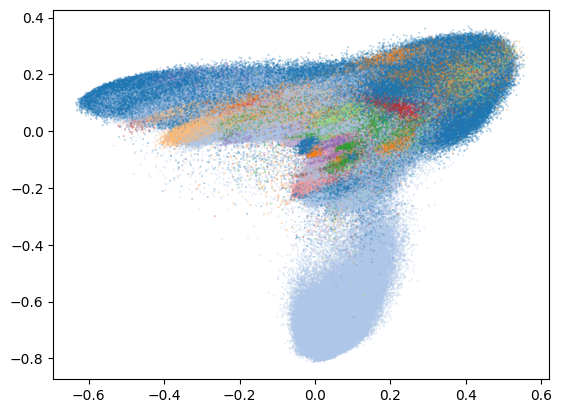

In [11]:
# 15 14M knn 20 Brain_NervousSystem
plt.scatter(coord_data[:,0], coord_data[:,1],
            c=encoded_labels, cmap="tab20", 
            s=0.1, alpha=0.5)
plt.show()